In [1]:
folder = 'hybrid_outputs' # 'hybrid_outputs_Tsense' # 
Tsense = '' # 'Tsense_' # 

In [2]:
import pickle
import os
import numpy as np
import matplotlib.pyplot as plt

def r2(y, p):
    m = ~(np.isnan(y) | np.isnan(p))
    y, p = y[m], p[m]
    return 1 - np.sum((y - p) ** 2) / np.sum((y - np.mean(y)) ** 2)

def analyse_one(temp, fold, md, mt, sat, targets, n_spatial, train_val_test):
    files = [fname for fname in os.listdir(folder) if f'hybrid_{Tsense}temp{temp}_fold{fold}_md{md}_mt{mt}_sat{sat}_targets{targets}_' in fname]
    files = sorted(files, key=len)
    with open(f'{folder}/'+files[n_spatial], 'rb') as f:
        results = pickle.load(f)
    test_R2s = {}
    for target in targets.split('-'):
        test_idx = results['split'] == train_val_test
        tar = results[f'target_{target}'][test_idx]
        pred = results[f'pred_{target}'][test_idx]
        r2_value = r2(tar.values, pred.values)
        test_R2s[target] = float(r2_value)
    return test_R2s

def get_all_n_sp(temp, fold, md, mt, sat, targets, train_val_test):
    all = []
    for i in range(20):
        try:
            all.append(analyse_one(temp, fold, md, mt, sat, targets, i, train_val_test))
        except:
            pass
    return all

def full_plot(temp, md, mt, sat, train_val_test):
    target_sets = ['SOC', 'SOC-MIC', 'SOC-MAOC', 'SOC-MAOC-MIC']  # 4 columns
    all_targets = ['SOC', 'MAOC', 'MIC']  # 3 possible targets as rows
    fig, axs = plt.subplots(len(all_targets), len(target_sets), figsize=(5 * len(target_sets), 4 * len(all_targets)), squeeze=False)
    for col_idx, targets in enumerate(target_sets):
        split_targets = targets.split('-')
        for row_idx, target in enumerate(all_targets):
            ax = axs[row_idx, col_idx]
            if target in split_targets:
                all_scores = []
                for fold in range(10):
                    fold_results = get_all_n_sp(
                        temp, fold, md, mt, sat, targets, train_val_test)
                    fold_target_r2s = [x[target] for x in fold_results if target in x]
                    all_scores.append(fold_target_r2s)
                for i, fold_scores in enumerate(all_scores):
                    ax.plot(range(len(fold_scores)), fold_scores, label=f'Fold {i+1}')
                ax.set_xlabel("# spatially varying parameters")
                ax.set_ylabel(f"{target} R2 Score")
                ax.set_title(f"Constraints {targets}")
                ax.set_ylim(-1, 1)  # Force y axis between -1 and 1
                ax.set_xlim(0, 8)  # Force y axis between -1 and 1
            else:
                ax.set_visible(False)
    plt.tight_layout()

def full_plot(temp, md, mt, sat, train_val_test):
    target_sets = ['SOC', 'SOC-MIC', 'SOC-MAOC', 'SOC-MAOC-MIC']  # 4 columns
    all_targets = ['SOC', 'MAOC', 'MIC']  # 3 possible targets, now as lines
    # Define colors per target
    target_colors = {'SOC': 'brown', 'MAOC': 'yellow', 'MIC': 'orange'}
    # Only one row, columns per constraint set
    fig, axs = plt.subplots(1, len(target_sets), figsize=(5 * len(target_sets), 4), squeeze=False)
    # Add parent plot title (md, mt, sat)
    fig.suptitle(f"md: {md}, mt: {mt}, sat: {sat}", fontsize=16, y=1.05)
    for col_idx, targets in enumerate(target_sets):
        split_targets = targets.split('-')
        ax = axs[0, col_idx]
        for target in all_targets:
            if target in split_targets:
                all_scores = []
                for fold in range(10):
                    fold_results = get_all_n_sp(
                        temp, fold, md, mt, sat, targets, train_val_test)
                    fold_target_r2s = [x[target] for x in fold_results if target in x]
                    all_scores.append(fold_target_r2s)
                # Plot all folds for this target in its color
                for i, fold_scores in enumerate(all_scores):
                    ax.plot(
                        range(len(fold_scores)), 
                        fold_scores, 
                        color=target_colors[target],
                        alpha=0.5,
                        label=f'{target} fold {i+1}' if i == 0 else ""  # Only label once for legend
                    )
        # Add a horizontal line at y=0
        ax.axhline(0, color='gray', linestyle='--', linewidth=1)
        ax.set_xlabel("# spatially varying parameters")
        ax.set_ylabel("R2 Score")
        ax.set_title(f"Constraints {targets}")
        ax.set_ylim(-1, 1)  # Force y axis between -1 and 1
        ax.set_xlim(0, 8)  
        # Show color legend just once per target
        handles, labels = ax.get_legend_handles_labels()
        new_handles_labels = {}
        for handle, label in zip(handles, labels):
            if label and label.split()[0] not in new_handles_labels:
                new_handles_labels[label.split()[0]] = handle
        ax.legend(new_handles_labels.values(), new_handles_labels.keys())
    plt.tight_layout(rect=[0, 0, 1, 0.97])  # Make room for suptitle above

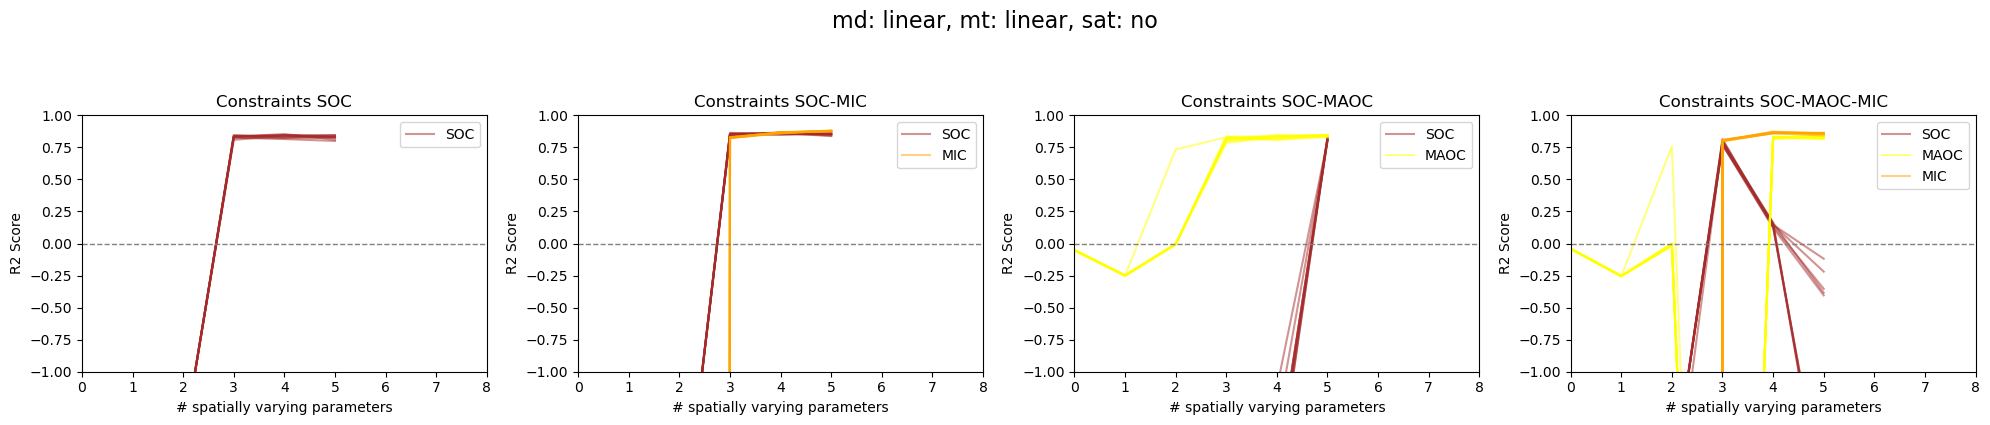

In [3]:
# baseline linear model
full_plot('static', 'linear', 'linear', 'no', 'test')

50% of the SOC variability can be explained with a purely linear decomposition model, while the use of additional spatially varying parameters always improves the predictions.  
Trying to explain MIC or MAOC patterns at the same time works as well, although imposing both at the same time leads to conflicts, the linear model can not resolve.

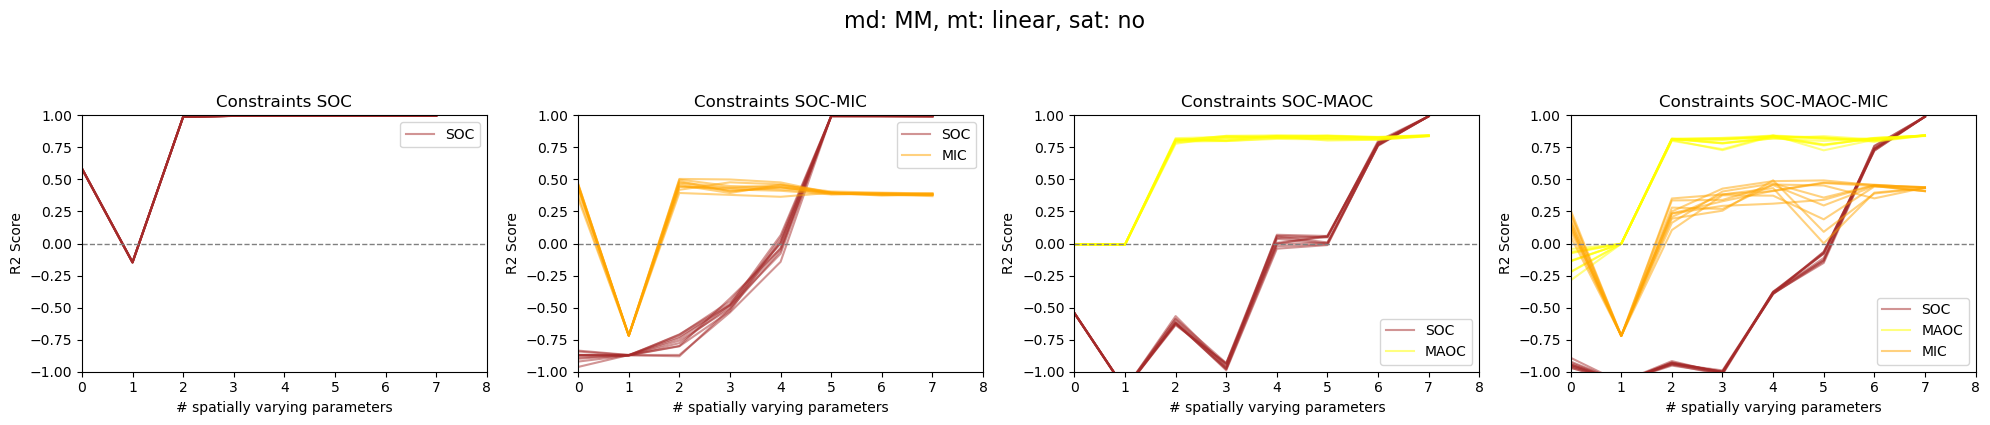

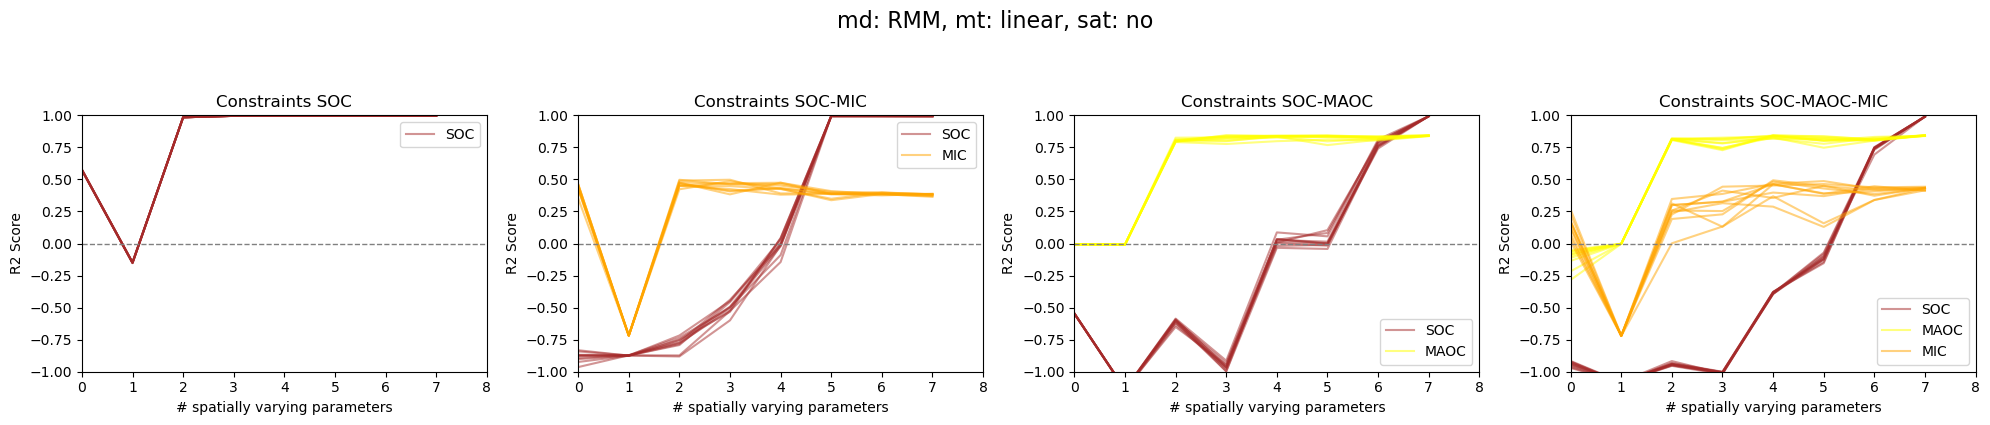

In [4]:
# MM and RMM decomposition models
full_plot('static', 'MM', 'linear', 'no', 'test')
full_plot('static', 'RMM', 'linear', 'no', 'test')

Non-linear decomposition mechanistics as MM or RMM allow the model to explain all explainable (as predicted with XBG before) variation of SOC.  
For that only 5 of 7 possible spatially varying parameters were necessary.  
The SOC-MIC relations could not be represented by the models at all, but the SOC-MAOC pattern could be explained when all 7 parameters could vary spatially.  

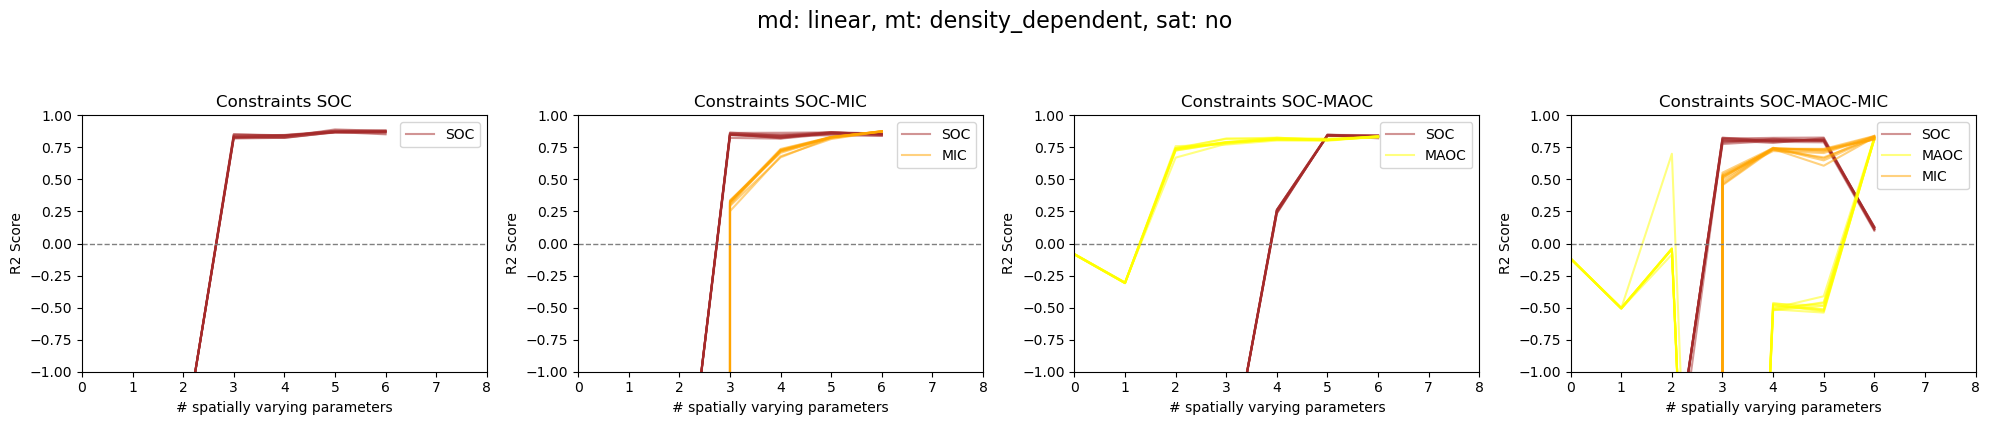

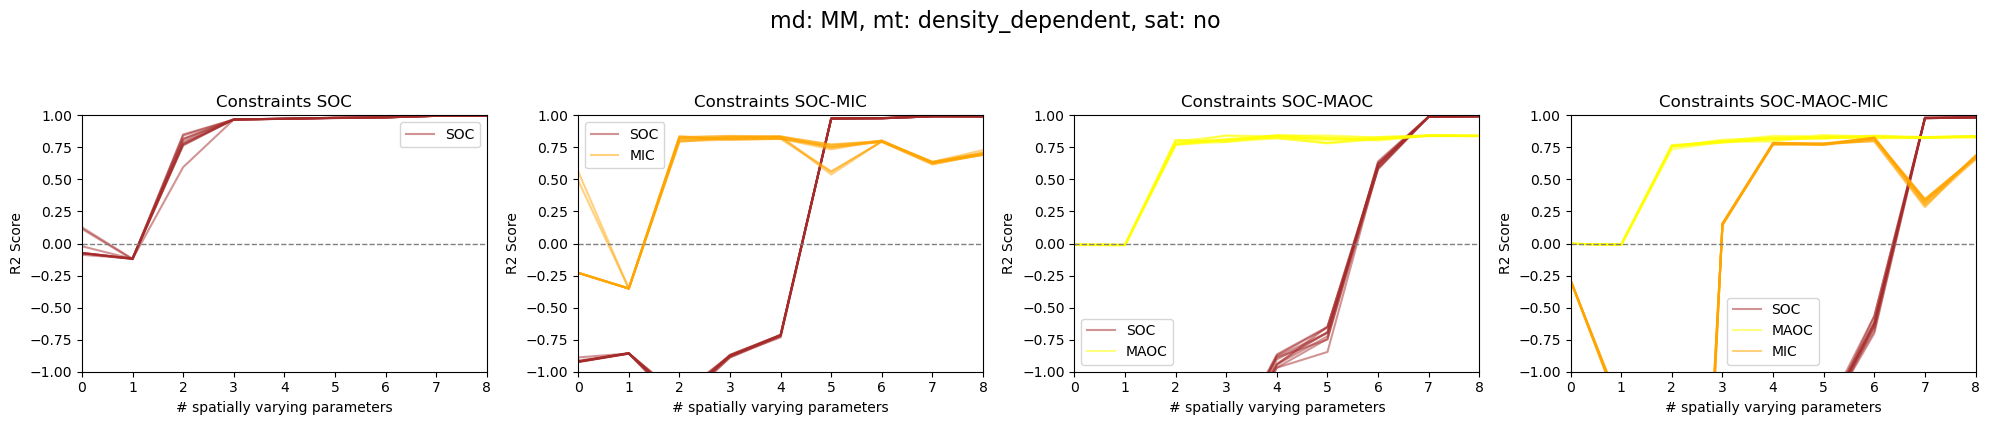

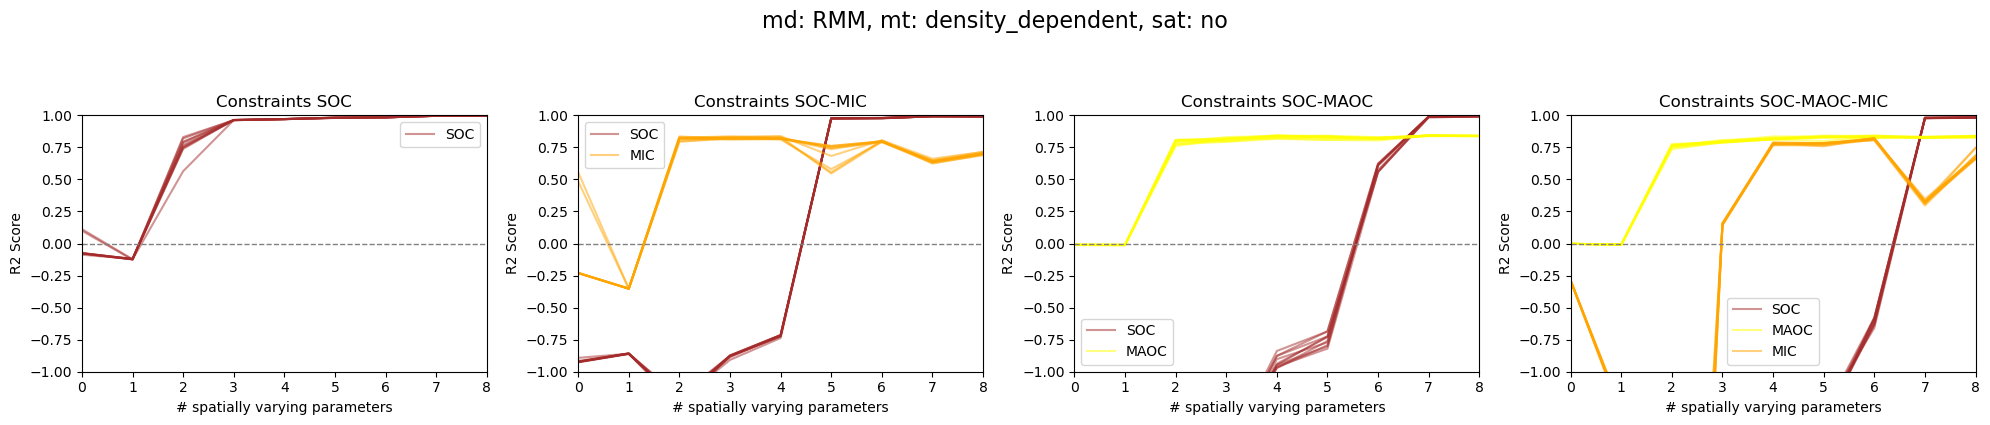

In [5]:
# density-dependent turnover
full_plot('static', 'linear', 'density_dependent', 'no', 'test')
full_plot('static', 'MM', 'density_dependent', 'no', 'test')
full_plot('static', 'RMM', 'density_dependent', 'no', 'test')

The additional parameter in the density-dependent, but by other means linear model improves predictions slightly compared to the fully linear model.  
The MM and RMM decomposition versions with density-dependent turnover can represent now also SOC-MIC patterns well, while the linear decomposition and density-dependent turnover model still shows conficts when imposing SOC-MIC.  
Also the full combination of constraints SOC-MIC-MAOC can be represented by the (R)MM decomposition & density-dependent microbial turnover models.

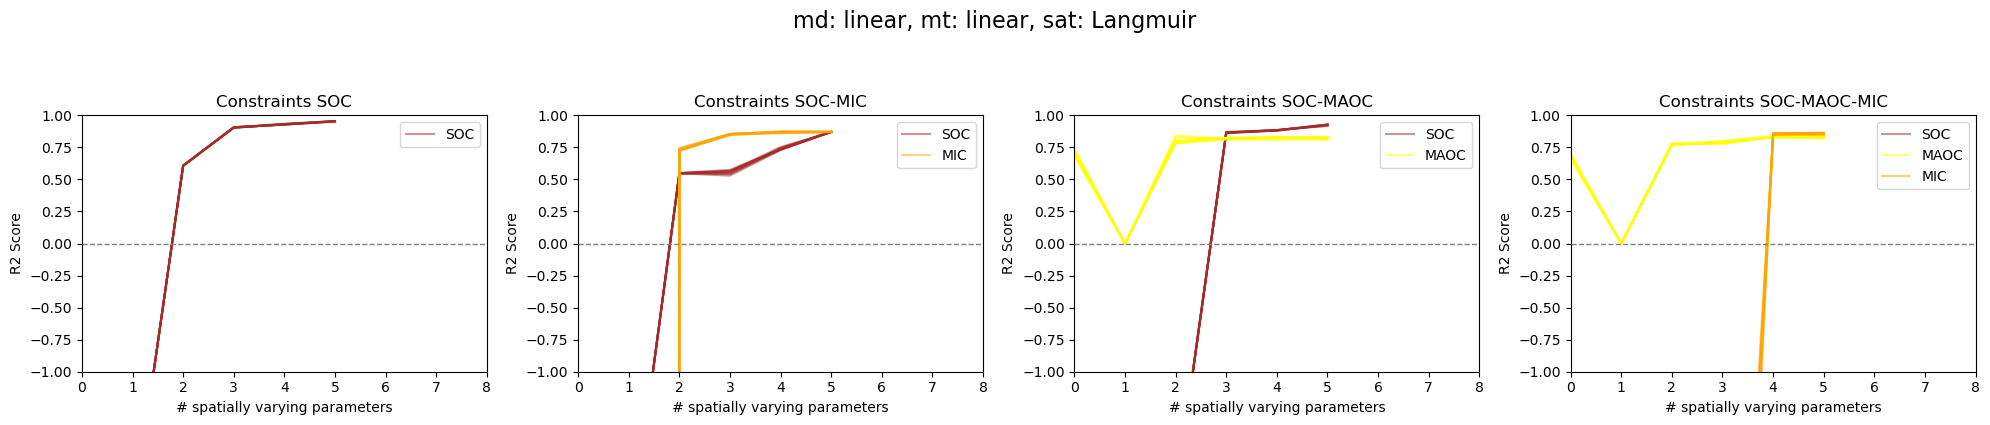

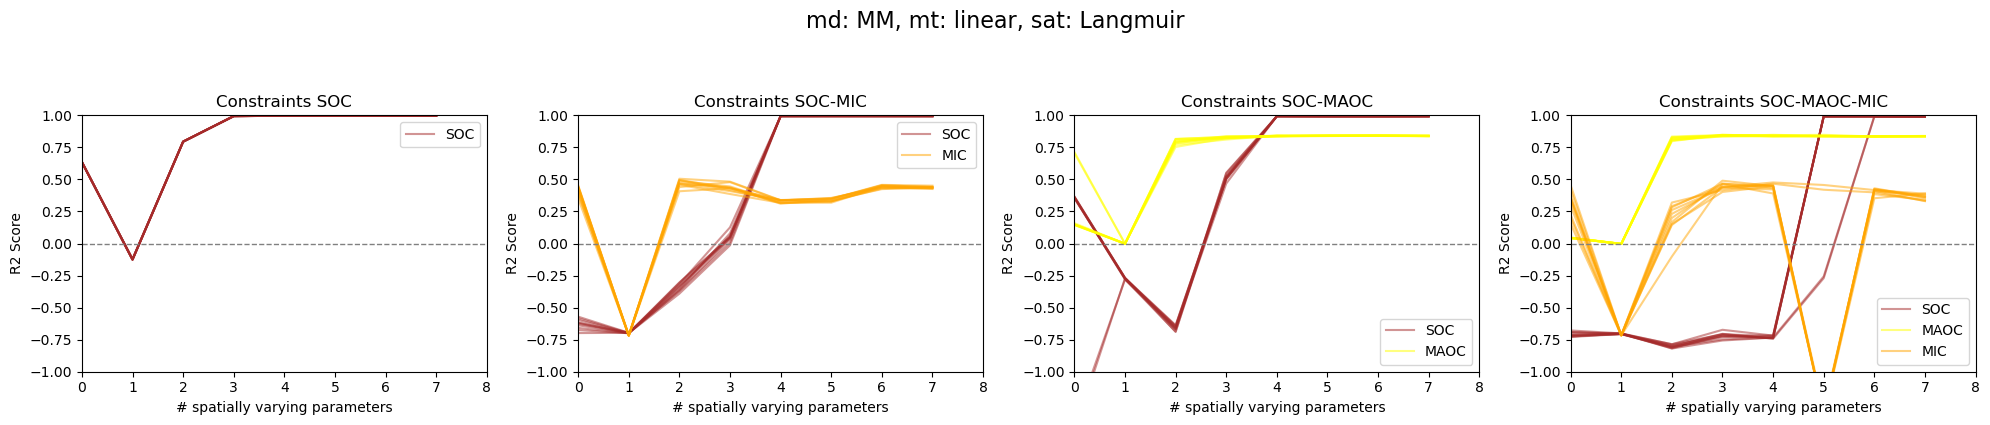

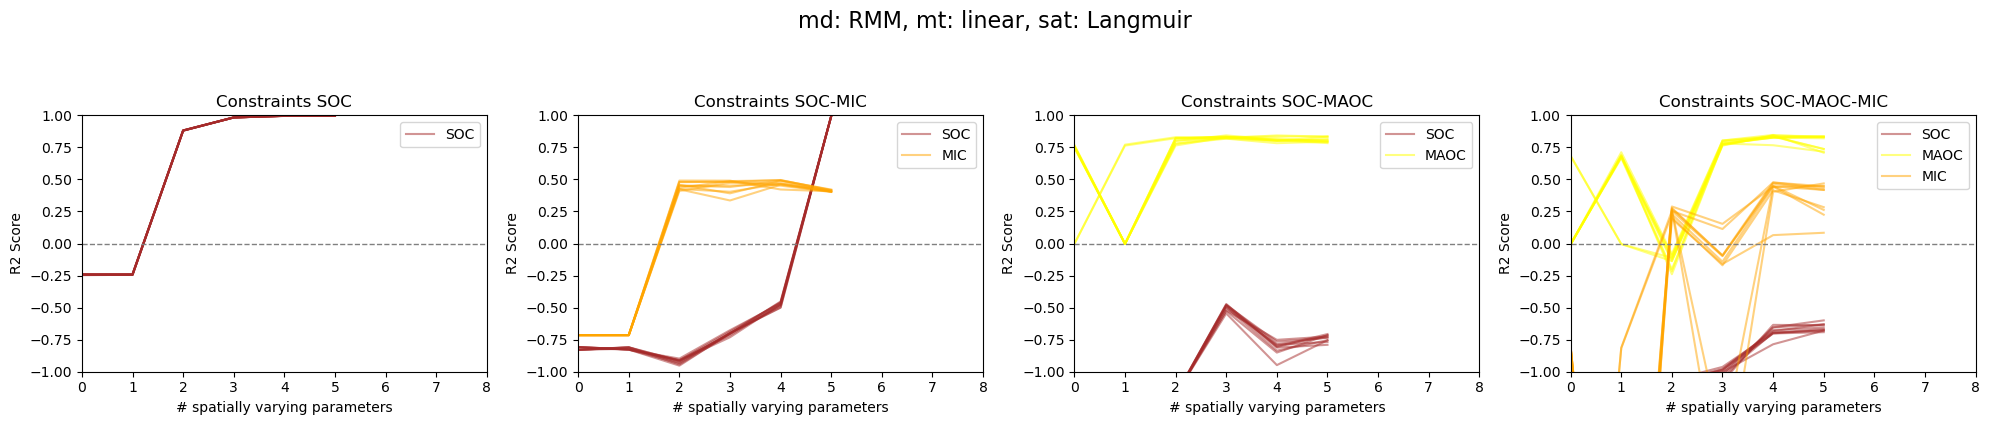

In [6]:
# Langmuir saturation
full_plot('static', 'linear', 'linear', 'Langmuir', 'test')
full_plot('static', 'MM', 'linear', 'Langmuir', 'test')
full_plot('static', 'RMM', 'linear', 'Langmuir', 'test')

The use of Langmuir saturation actually harms the models flexibility already in the linear decomposition case considering only SOC patterns.  
This behavior also shows with (R)MM models and only SOC, while they are hardy able to represent the full pattern in the case of maximum spatially varying parameters.  
SOC-MIC patterns can't be represented at all when Langmuir saturation is applied.  
While also SOC-MAOC patterns are not representable if Langmuir saturation applies with linear or RMM decomposition, Langmuir with MM decomposition strikes with good performance here.  

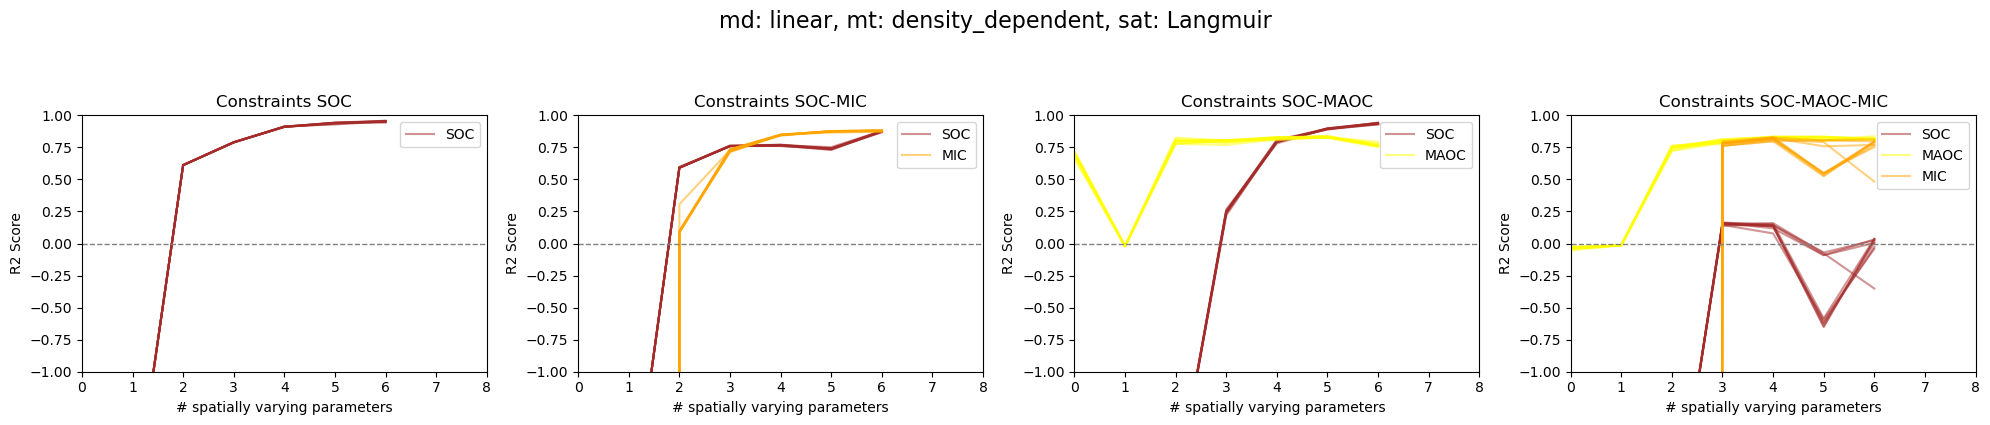

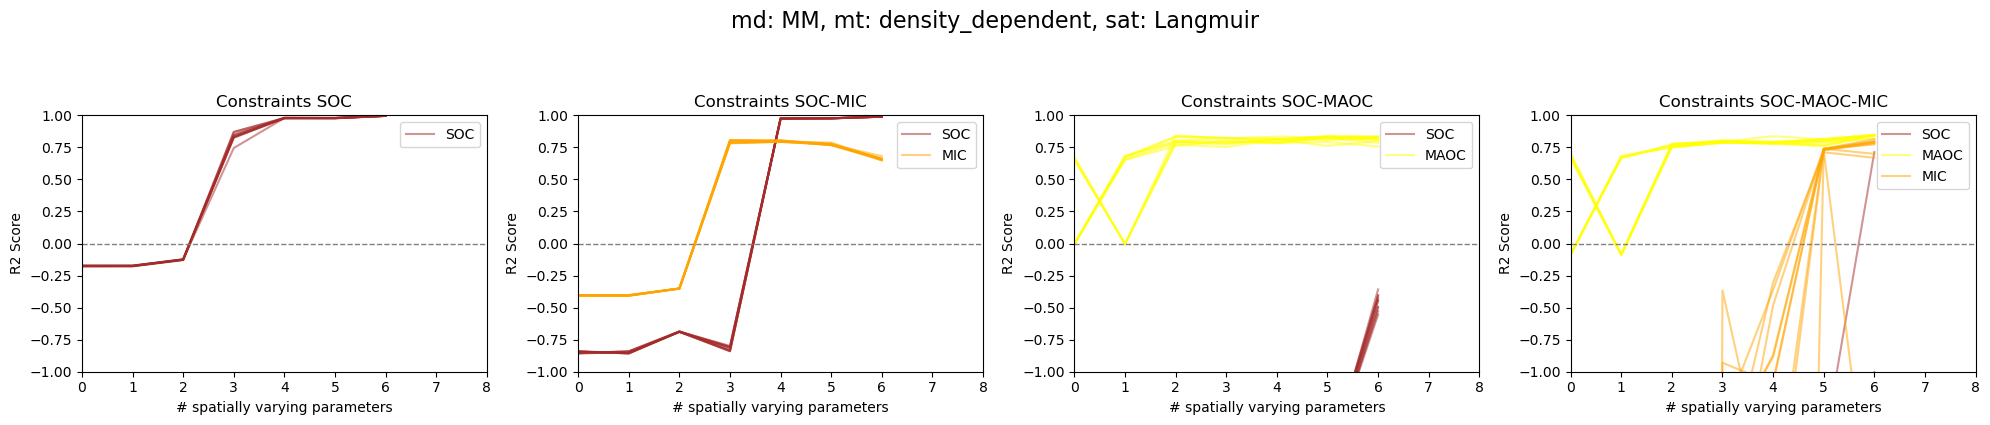

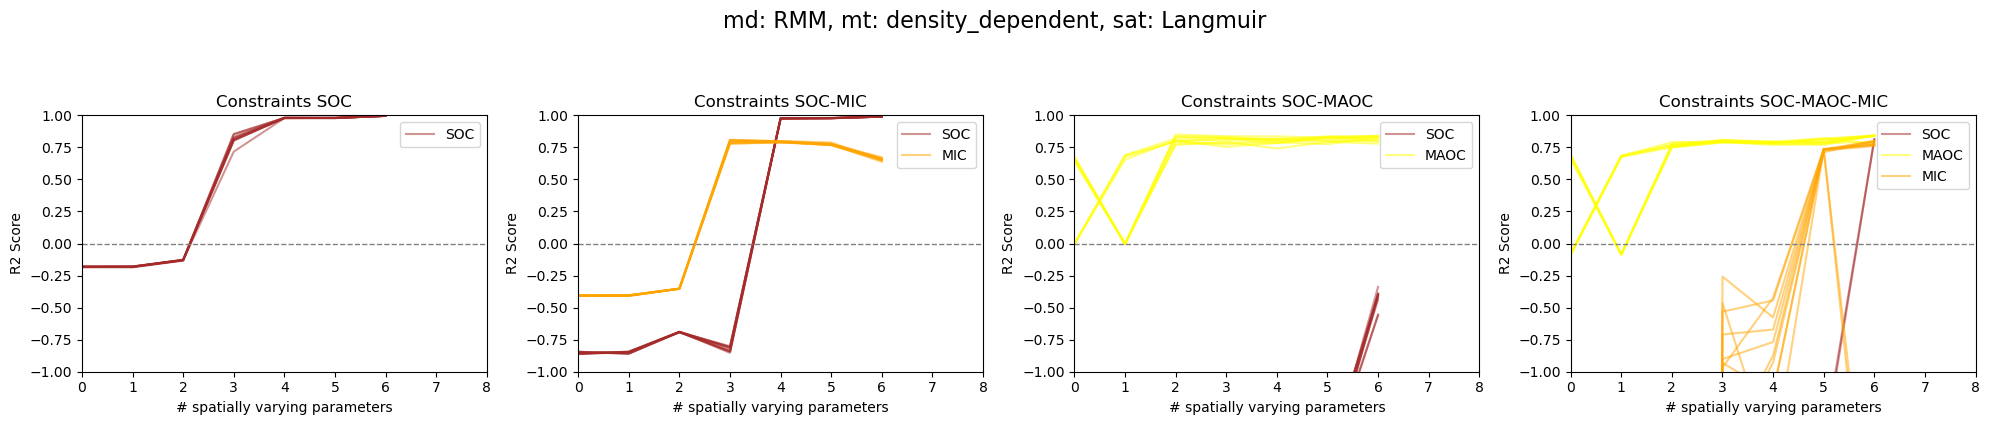

In [7]:
# density-dependent trunover & Langmuir saturation
full_plot('static', 'linear', 'density_dependent', 'Langmuir', 'test')
full_plot('static', 'MM', 'density_dependent', 'Langmuir', 'test')
full_plot('static', 'RMM', 'density_dependent', 'Langmuir', 'test')

Are density-dependent turnover and Langmuir saturation applied together to the different decomposition models, the effects of both seem to be combined.  
While both SOC-MIC and SOC-MAOC patterns can be represented by the (R)MM versions, there seem to bee conflicts when SOC-MAOC-MIC patterns are imposed at the same time.

# Summary:
- Linear decomposition models can not explain the observed NPP SOC relationship, but MM and RMM can.  
- MM and RMM are enough to explain observed SOC-MAOC patterns.
- To explain also SOC-MIC patterns, density-dependent microbial turnover (+ MM/RMM) is necessary.
- Langmuir saturation mechanism harms the training.